In [42]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [43]:
sns.set_theme(
    style="whitegrid",
    context="paper",
    palette="PRGn",
    rc={
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.titlesize": 14
    }
)

In [3]:
df = pd.read_csv('diabetes_dataset.csv')

In [4]:
df.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [47]:
categorical_vars = [
    "gender",
    "ethnicity",
    "education_level",
    "income_level",
    "employment_status",
    "smoking_status",
    "alcohol_consumption_per_week",
    "family_history_diabetes",
    "hypertension_history",
    "cardiovascular_history",
    "diabetes_stage",
    "diagnosed_diabetes"
]

continuous_vars = [
    "age",
    "physical_activity_minutes_per_week",
    "diet_score",
    "sleep_hours_per_day",
    "screen_time_hours_per_day",
    "bmi",
    "waist_to_hip_ratio",
    "systolic_bp",
    "diastolic_bp",
    "heart_rate",
    "cholesterol_total",
    "hdl_cholesterol",
    "ldl_cholesterol",
    "triglycerides",
    "glucose_fasting",
    "glucose_postprandial",
    "insulin_level",
    "hba1c",
    "diabetes_risk_score"
]

In [6]:
demographics = [
    "age",
    "gender",
    "ethnicity",
    "education_level",
    "income_level",
    "employment_status"
]

lifestyle = [
    "smoking_status",
    "alcohol_consumption_per_week",
    "physical_activity_minutes_per_week",
    "diet_score",
    "sleep_hours_per_day",
    "screen_time_hours_per_day"
]

medical_history = [
    "family_history_diabetes",
    "hypertension_history",
    "cardiovascular_history"
]

body_metrics = [
    "bmi",
    "waist_to_hip_ratio"
]

vital_signs = [
    "systolic_bp",
    "diastolic_bp",
    "heart_rate"
]

lipid_profile = [
    "cholesterol_total",
    "hdl_cholesterol",
    "ldl_cholesterol",
    "triglycerides"
]

diabetes_biomarkers = [
    "glucose_fasting",
    "glucose_postprandial",
    "insulin_level",
    "hba1c"
]

diabetes_outcomes = [
    "diabetes_risk_score",
    "diabetes_stage",
    "diagnosed_diabetes"
]

target = "diagnosed_diabetes"

## Quality of the data

In [7]:
df.shape

(100000, 31)

The dataset contains 31 parameters for 100.000 patients and has no missing values.

The parameters can be classified in x categories: 
- demographics
- lifestyle
- medical history
- medical data
- diabetes descriptors



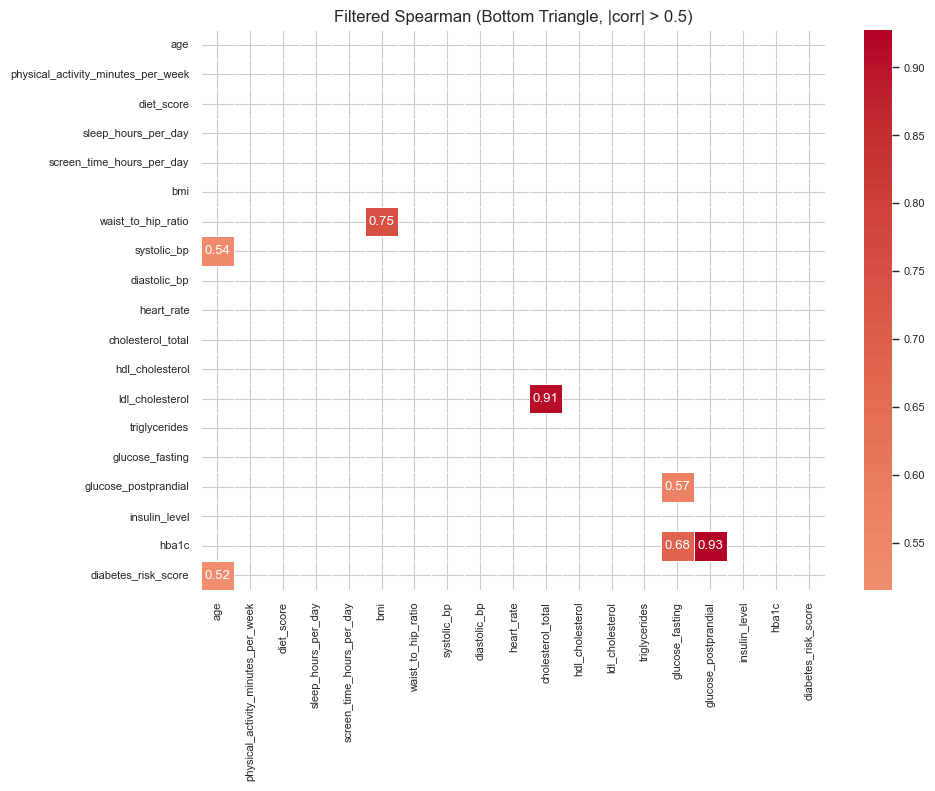

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Compute correlations
spearman_corr = df[continuous_vars].corr(method="spearman")

threshold = 0.5

# Filter correlations
filtered_corr = spearman_corr.copy()
filtered_corr[(filtered_corr.abs() < threshold)] = np.nan

# Create mask for upper triangle
mask = np.triu(np.ones_like(filtered_corr, dtype=bool))

plt.figure(figsize=(10, 8))

sns.heatmap(
    filtered_corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Filtered Spearman (Bottom Triangle, |corr| > 0.5)")
plt.tight_layout()
plt.show()

In [24]:
import pandas as pd
import numpy as np

def get_top_correlations(corr_matrix, n=10):
    corr = corr_matrix.copy()
    
    # Remove self-correlations
    np.fill_diagonal(corr.values, np.nan)
    
    # Unstack and sort
    corr_pairs = (
        corr.unstack()
        .dropna()
        .reset_index()
    )
    
    corr_pairs.columns = ["Variable_1", "Variable_2", "Correlation"]
    
    # Remove duplicate pairs (A-B same as B-A)
    corr_pairs["pair"] = corr_pairs.apply(
        lambda x: tuple(sorted([x["Variable_1"], x["Variable_2"]])),
        axis=1
    )
    
    corr_pairs = corr_pairs.drop_duplicates("pair").drop(columns="pair")
    
    # Sort by absolute correlation
    corr_pairs["abs_corr"] = corr_pairs["Correlation"].abs()
    
    return corr_pairs.sort_values("abs_corr", ascending=False).head(n)

In [25]:
top_pearson = get_top_correlations(pearson_corr, n=15)
top_spearman = get_top_correlations(spearman_corr, n=15)

print("Top Pearson Correlations:")
display(top_pearson)

print("Top Spearman Correlations:")
display(top_spearman)

Top Pearson Correlations:


,Variable_1,Variable_2,Correlation,abs_corr
321,glucose_postprandial,hba1c,0.933145,0.933145
221,cholesterol_total,ldl_cholesterol,0.906132,0.906132
120,bmi,waist_to_hip_ratio,0.765744,0.765744
302,glucose_fasting,hba1c,0.700352,0.700352
300,glucose_fasting,glucose_postprandial,0.589126,0.589126
7,age,systolic_bp,0.547696,0.547696
18,age,diabetes_risk_score,0.495924,0.495924
303,glucose_fasting,diabetes_risk_score,0.469938,0.469938
127,bmi,triglycerides,0.405668,0.405668
130,bmi,insulin_level,0.391903,0.391903


Top Spearman Correlations:


,Variable_1,Variable_2,Correlation,abs_corr
321,glucose_postprandial,hba1c,0.927333,0.927333
221,cholesterol_total,ldl_cholesterol,0.906678,0.906678
120,bmi,waist_to_hip_ratio,0.750737,0.750737
302,glucose_fasting,hba1c,0.683832,0.683832
300,glucose_fasting,glucose_postprandial,0.571472,0.571472
7,age,systolic_bp,0.535197,0.535197
18,age,diabetes_risk_score,0.515438,0.515438
303,glucose_fasting,diabetes_risk_score,0.448698,0.448698
127,bmi,triglycerides,0.391336,0.391336
130,bmi,insulin_level,0.381069,0.381069


In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

def plot_variable_grid(df, variables, continuous_vars, cols=3, figsize_scale=3, hue=None):
    """
    Plots a grid of variables:
    - histplot for continuous variables
    - countplot for categorical variables
    """
    
    rows = math.ceil(len(variables) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * figsize_scale, rows * figsize_scale))
    
    # Handle case when only 1 row
    if rows == 1:
        axes = [axes] if cols == 1 else axes.flatten()
    else:
        axes = axes.flatten()
    
    for i, var in enumerate(variables):
        ax = axes[i]
        
        if var in continuous_vars:
            sns.histplot(data=df, x=var, kde=True, ax=ax, hue=hue, multiple='stack')
        else:
            sns.countplot(data=df, x=var, ax=ax, hue=hue)
            ax.tick_params(axis='x', rotation=45)
        
        ax.set_title(var)
    
    # Remove empty subplots
    for i in range(len(variables), len(axes)):
        fig.delaxes(axes[i])
    
    plt.tight_layout()
    plt.show()

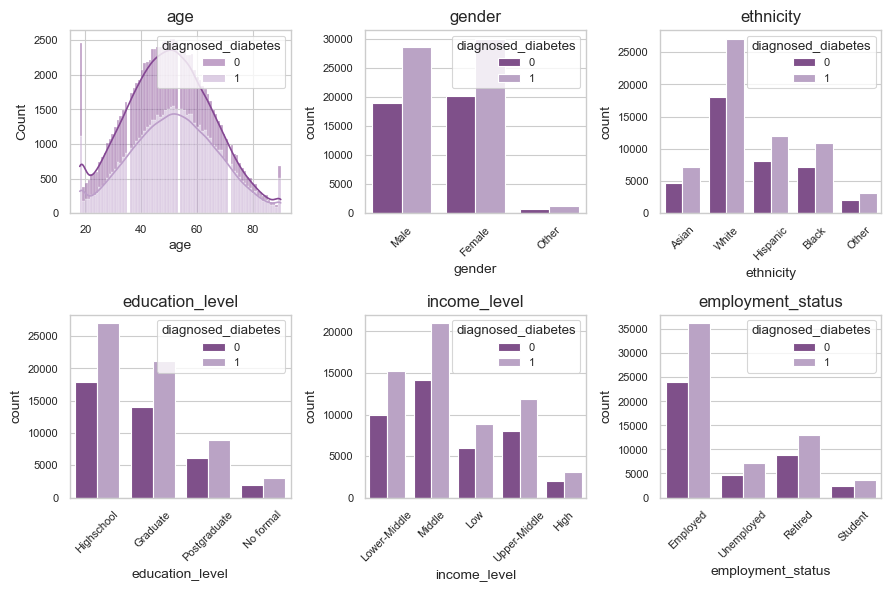

In [70]:
plot_variable_grid(df, demographics, continuous_vars, cols=3, hue='diagnosed_diabetes')

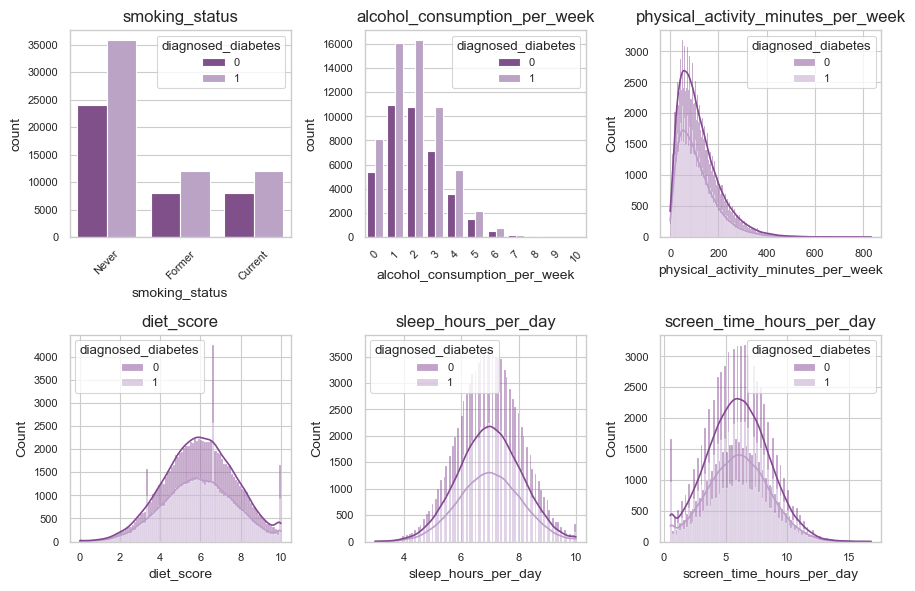

In [61]:
plot_variable_grid(df, lifestyle, continuous_vars, cols=3, hue='diagnosed_diabetes')

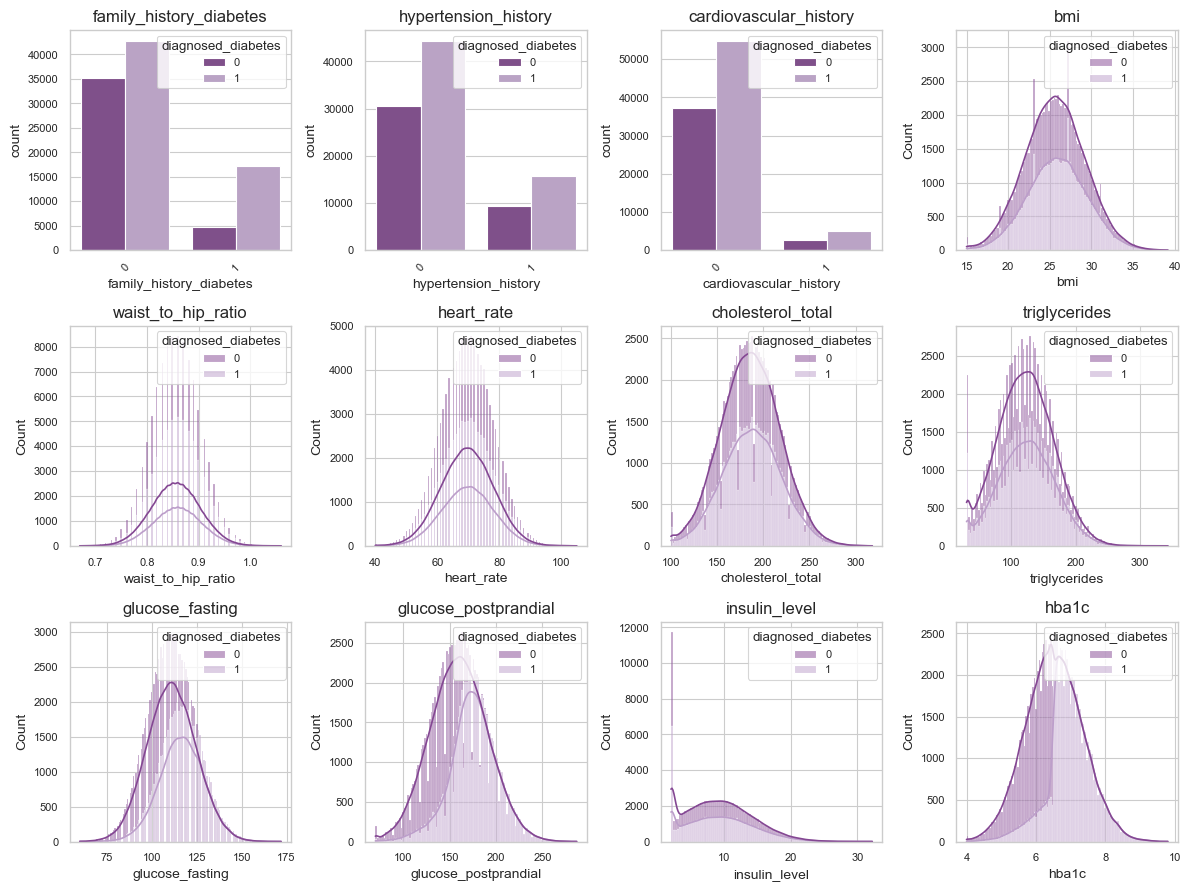

In [71]:
medical_variables = [
    "family_history_diabetes",
    "hypertension_history",
    "cardiovascular_history",
    "bmi",
    "waist_to_hip_ratio",
    "heart_rate",
    "cholesterol_total",
    "triglycerides",
    "glucose_fasting",
    "glucose_postprandial",
    "insulin_level",
    "hba1c"

]
plot_variable_grid(df, medical_variables, continuous_vars, cols=4, hue='diagnosed_diabetes')

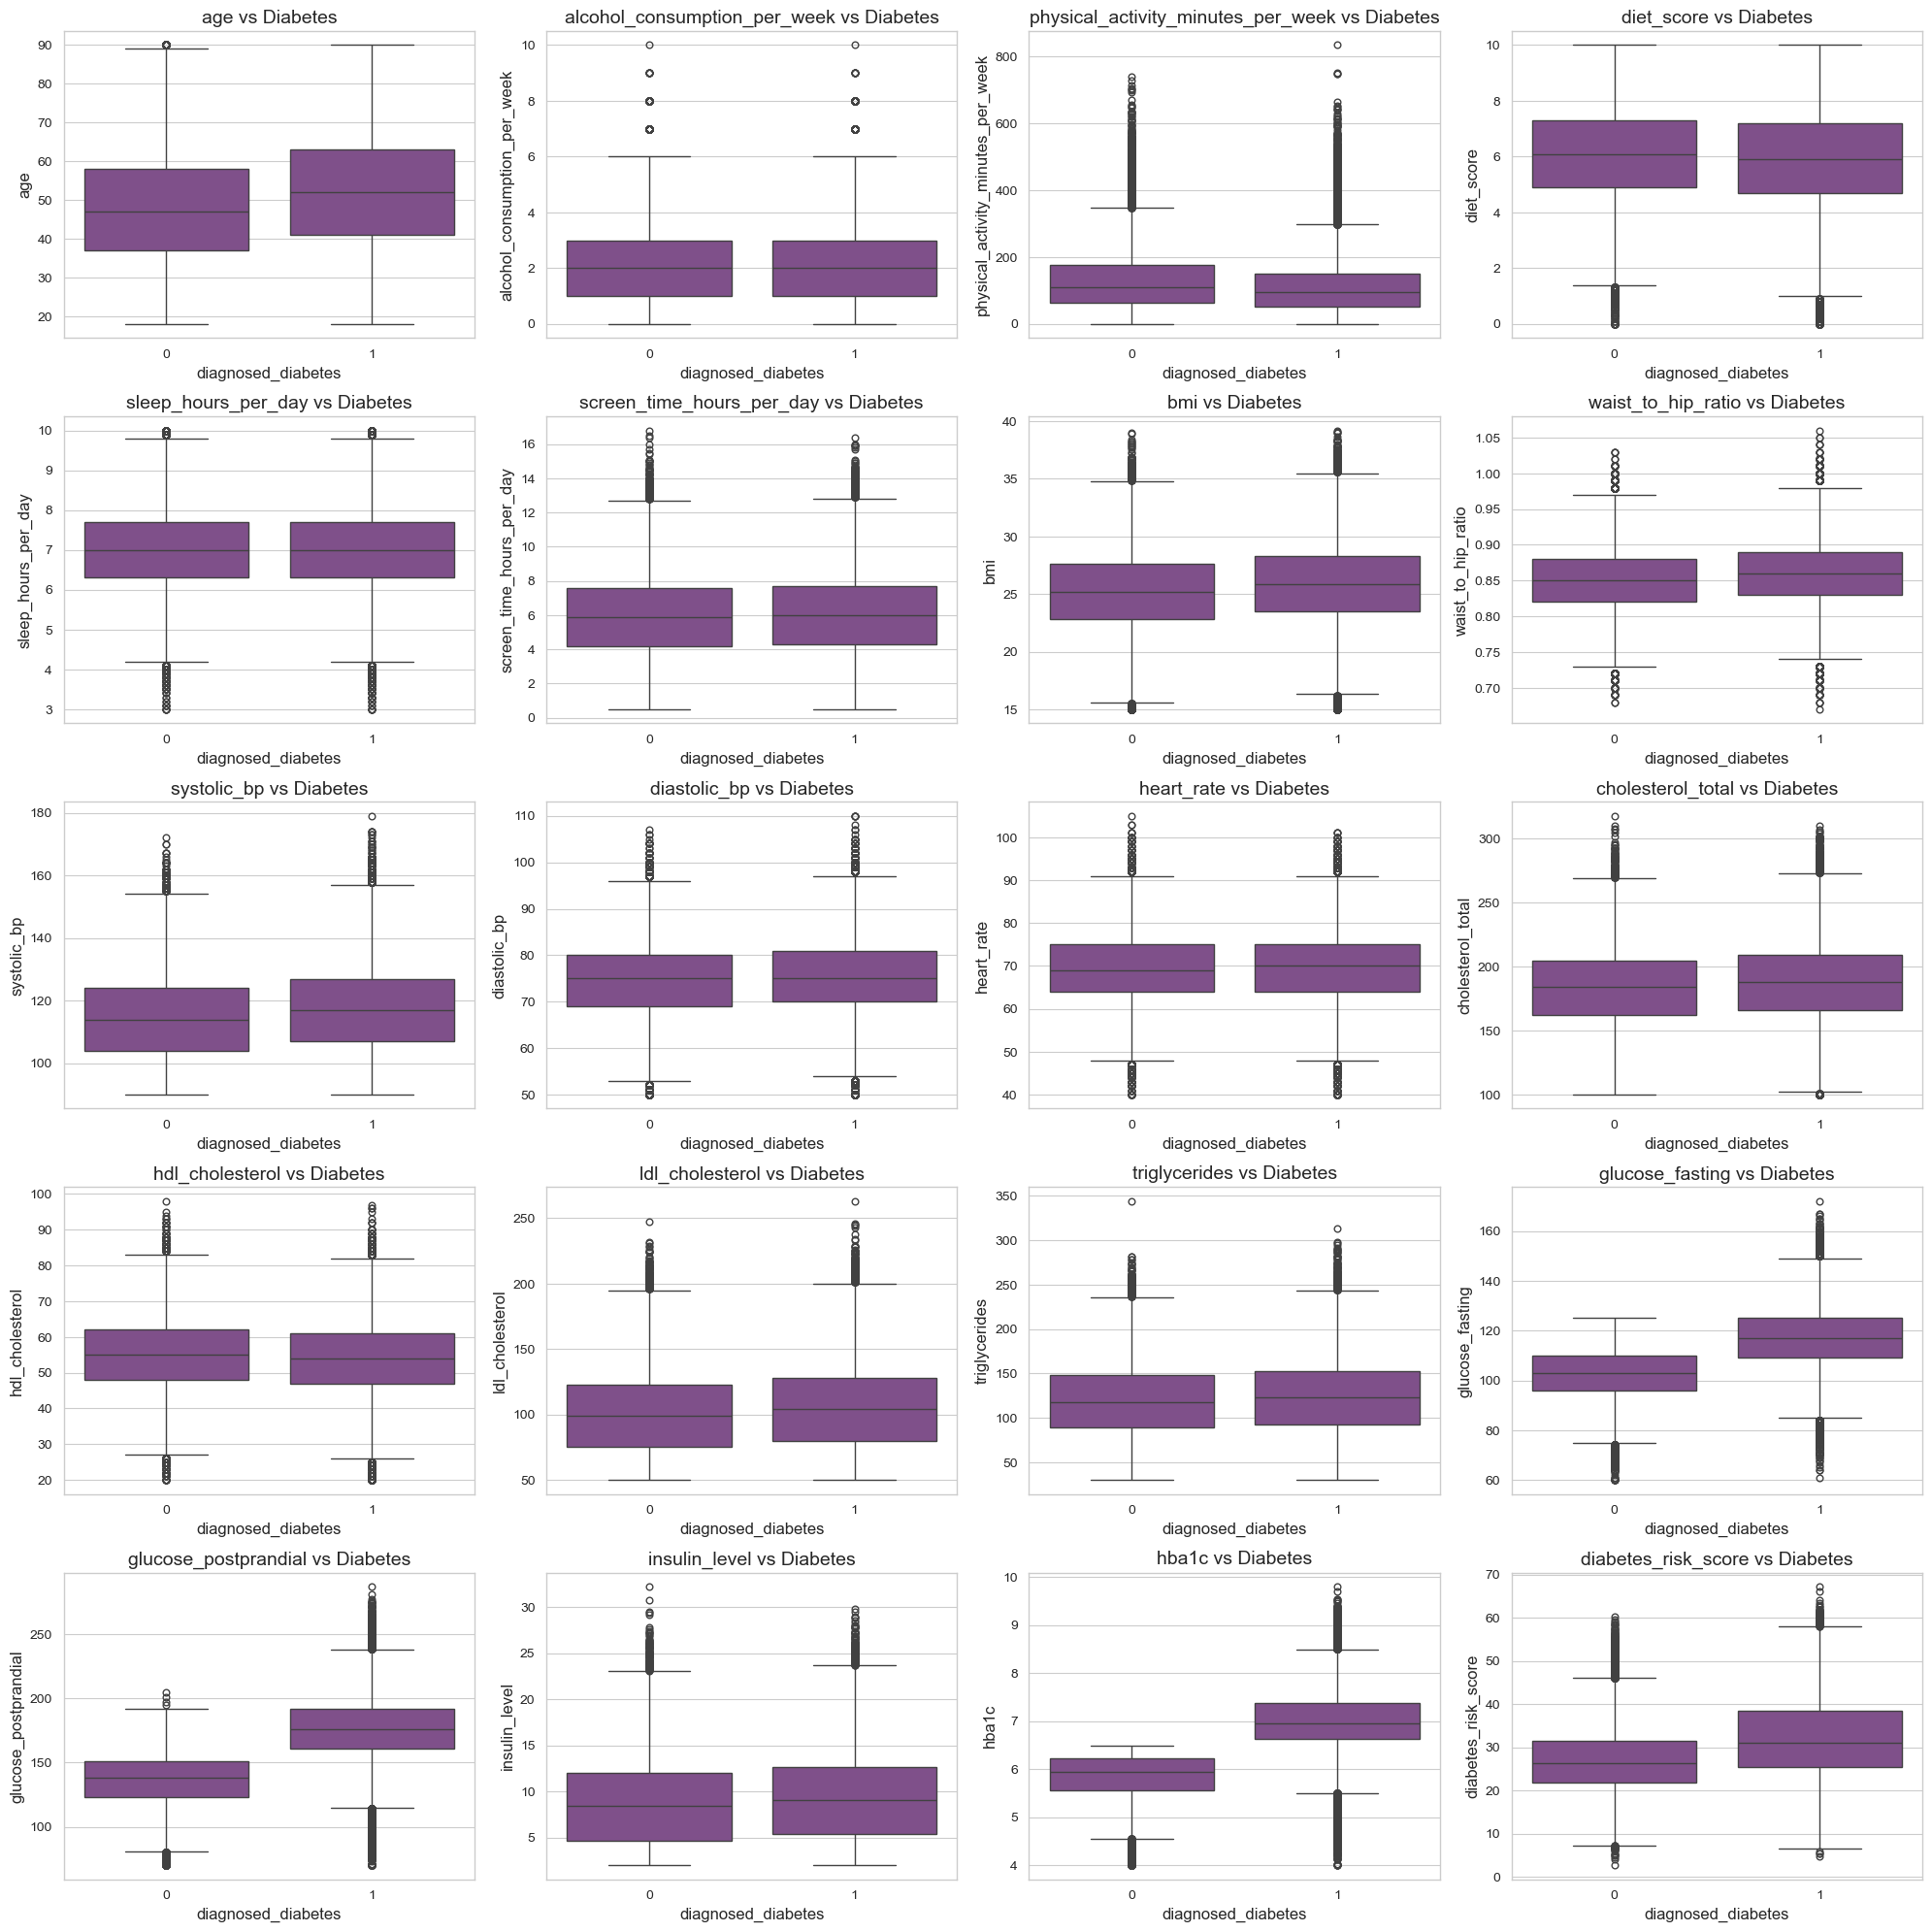

In [14]:
cols = 4
rows = math.ceil(len(continuous_vars) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flatten()

for i, col in enumerate(continuous_vars):
    sns.boxplot(data=df, x="diagnosed_diabetes", y=col, ax=axes[i])
    axes[i].set_title(f"{col} vs Diabetes")

for i in range(len(continuous_vars), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

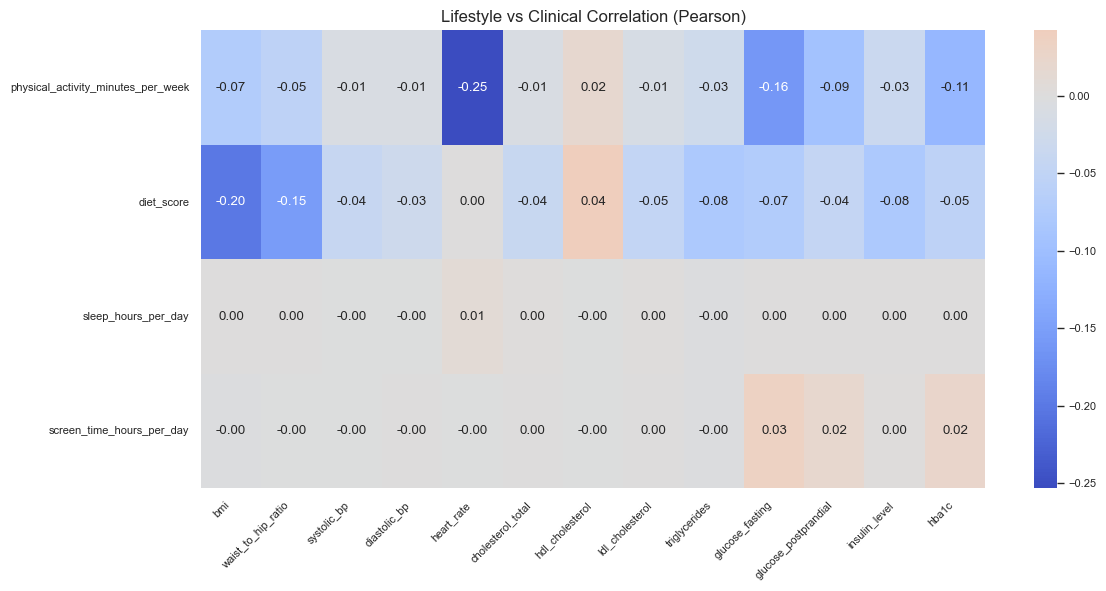

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only continuous lifestyle + clinical variables
lifestyle_cont = [col for col in lifestyle if col in continuous_vars]
clinical_vars = body_metrics + vital_signs + lipid_profile + diabetes_biomarkers

# Correlation matrix
corr_matrix = df[lifestyle_cont + clinical_vars].corr()

# Extract only lifestyle vs clinical part
cov_corr = corr_matrix.loc[lifestyle_cont, clinical_vars]

plt.figure(figsize=(12, 6))
sns.heatmap(cov_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Lifestyle vs Clinical Correlation (Pearson)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [76]:
cov_pairs = (
    cov_corr.unstack()
    .reset_index()
    .rename(columns={"level_0": "lifestyle_var", "level_1": "clinical_var", 0: "correlation"})
)

cov_pairs["abs_corr"] = cov_pairs["correlation"].abs()

top_covariates = cov_pairs.sort_values("abs_corr", ascending=False)

top_covariates.head(15)

,lifestyle_var,clinical_var,correlation,abs_corr
16,heart_rate,physical_activity_minutes_per_week,-0.253275,0.253275
1,bmi,diet_score,-0.201303,0.201303
36,glucose_fasting,physical_activity_minutes_per_week,-0.161946,0.161946
5,waist_to_hip_ratio,diet_score,-0.154968,0.154968
48,hba1c,physical_activity_minutes_per_week,-0.112897,0.112897
40,glucose_postprandial,physical_activity_minutes_per_week,-0.093936,0.093936
45,insulin_level,diet_score,-0.080716,0.080716
33,triglycerides,diet_score,-0.080243,0.080243
37,glucose_fasting,diet_score,-0.072518,0.072518
0,bmi,physical_activity_minutes_per_week,-0.071907,0.071907


In [79]:
from sklearn.feature_selection import mutual_info_regression

mi_scores = mutual_info_regression(
    df[lifestyle_cont],
    df["diabetes_risk_score"]
)

pd.Series(mi_scores, index=lifestyle_cont).sort_values(ascending=False)

physical_activity_minutes_per_week    0.102164
diet_score                            0.011430
screen_time_hours_per_day             0.006143
sleep_hours_per_day                   0.002900
dtype: float64